First step is to load the data from 'laptop_price - dataset.csv' into a variable called laptop_data.

In [9]:
import pandas as pd

def load_laptop_data(datafile="laptop_price - dataset.csv") -> pd.DataFrame:
    try:
        laptop_data = pd.read_csv(datafile)
        return laptop_data
    except FileNotFoundError as e:
        print(f"No such file '{datafile}' in this directory.")
        exit(e)
    except (pd.errors.ParserError, pd.errors.EmptyDataError) as e:
        print("There is some data error.")
        exit(e)

laptop_data = load_laptop_data()


Let's view the data.

In [10]:
laptop_data.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


Now, let's start with the tasks.
1. Plot the price of all the laptops

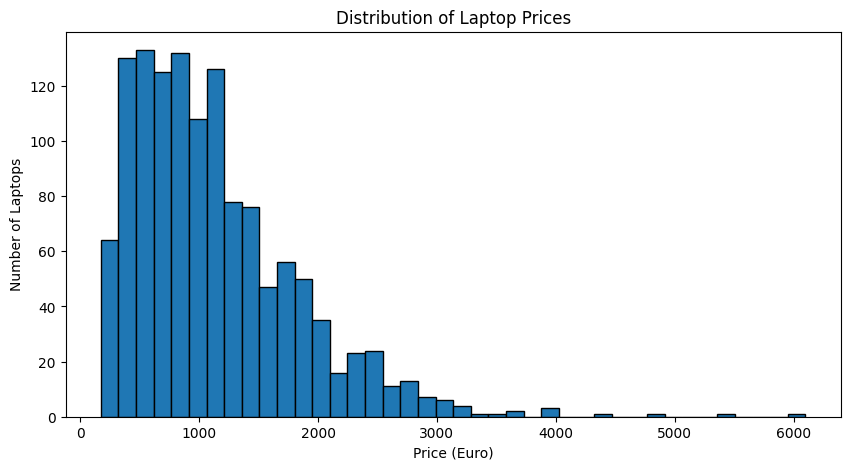

In [16]:
import matplotlib.pyplot as plt

def plot_laptop_prices(laptop_data: pd.DataFrame):
    # TODO change all magicstrings here to consts
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(laptop_data["Price (Euro)"], bins=40, edgecolor="black")
    ax.set_title("Distribution of Laptop Prices")
    ax.set_xlabel("Price (Euro)")
    ax.set_ylabel("Number of Laptops")
    return fig

plot_laptop_prices(laptop_data)
plt.show()

2. Which company has on average the most expensive laptop? What is the average laptop price for each company?

We can see below that Razer has the most expensive laptop on average. 
We can also see the average laptop price for each company in the chart.

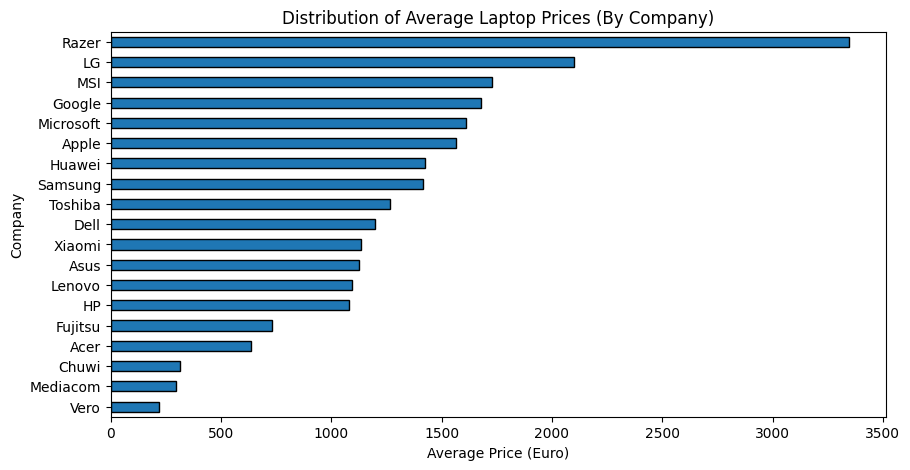

In [ ]:
def plot_avg_laptop_prices_by_company(laptop_data: pd.DataFrame):
    # TODO change all magicstrings here to consts
    fig, ax = plt.subplots(figsize=(10, 5))
    companies_avg = (
        laptop_data.groupby("Company")["Price (Euro)"]
        .mean()
        .sort_values(ascending=True)
    )
    companies_avg.plot(ax=ax, kind="barh", edgecolor="black")
    ax.set_title("Distribution of Average Laptop Prices (By Company)")
    ax.set_xlabel("Average Price (Euro)")
    ax.set_ylabel("Company")
    return fig

plot_avg_laptop_prices_by_company(laptop_data)
plt.show()

3. Find the different types of Operating systems present in the data - under the column name "OpSys".
Please note - there are operating systems that are the same systems and just written differently in the column - please fix them to be uniform.

To solve that I listed all unique OS names to check what OS names have different flavors.


In [20]:
unique_os_names = laptop_data["OpSys"].unique()
print(unique_os_names)

['macOS' 'No OS' 'Windows 10' 'Mac OS X' 'Linux' 'Android' 'Windows 10 S'
 'Chrome OS' 'Windows 7']


I saw that only Mac and Windows were general so I created a function to simplify them:

In [22]:
def simplify_os(name: str):
    lowered_name = name.lower()
    if "windows" in lowered_name:
        return "Windows"
    if "mac" in lowered_name:
        return "macOS"
    return name

def generalize_column_opsys(laptop_data: pd.DataFrame):
    data_copy = laptop_data.copy()
    # TODO change OpSys to a const
    data_copy["OpSys"] = data_copy["OpSys"].apply(simplify_os)
    return data_copy

new_laptop_data = generalize_column_opsys(laptop_data)
unique_opsys = new_laptop_data["OpSys"].unique()
print(unique_opsys)

['macOS' 'No OS' 'Windows' 'Linux' 'Android' 'Chrome OS']


4. Plot for each of the operating system types the distribution of the prices, so that the number of plots equals to the number of unique operating systems.

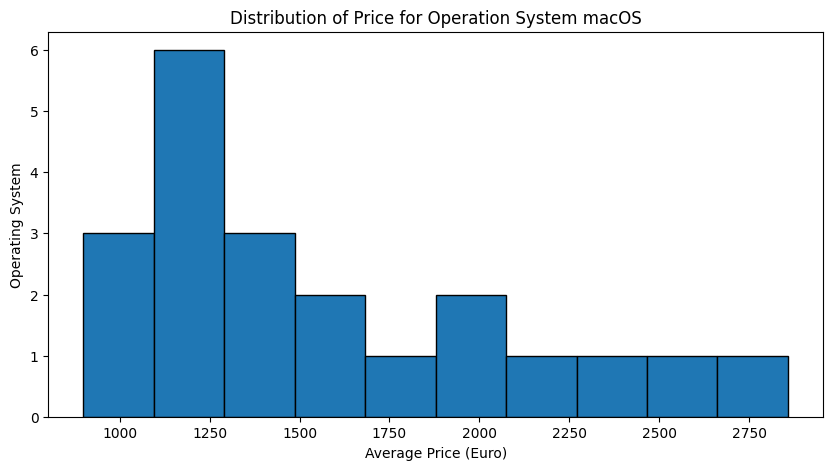

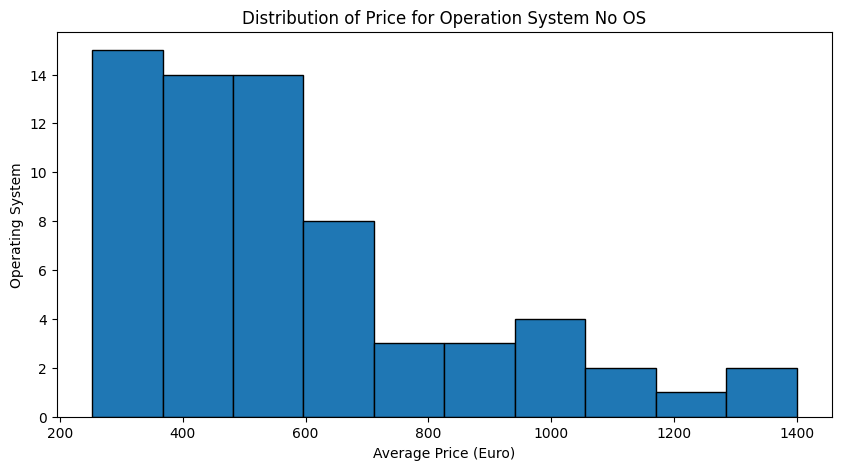

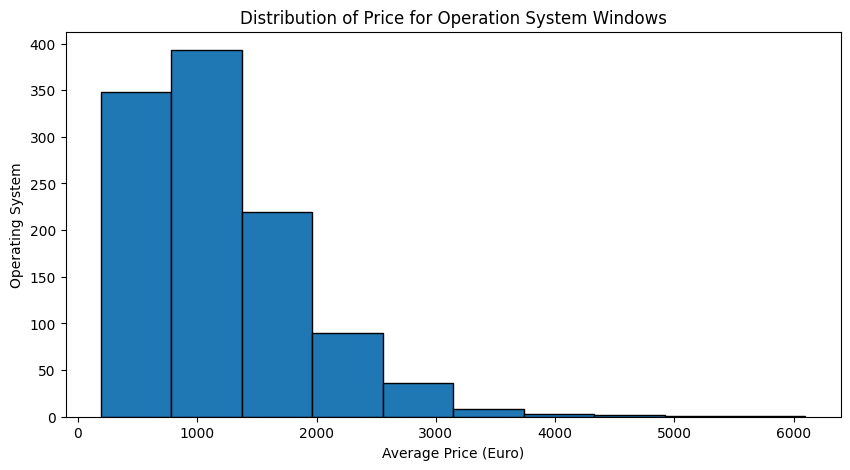

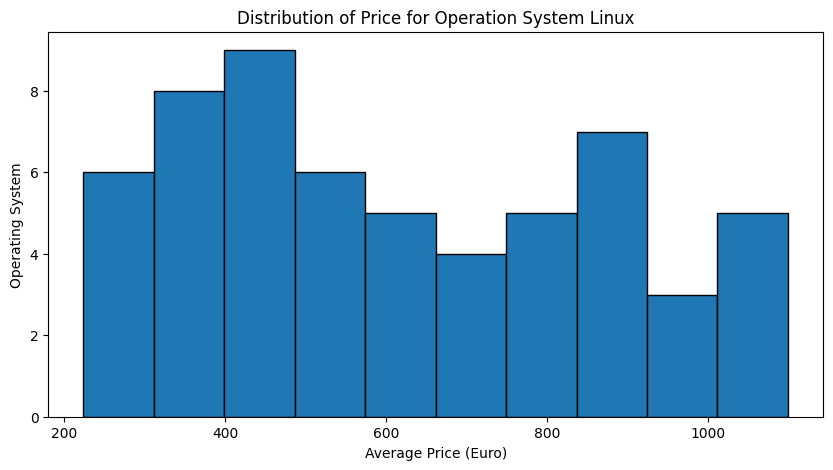

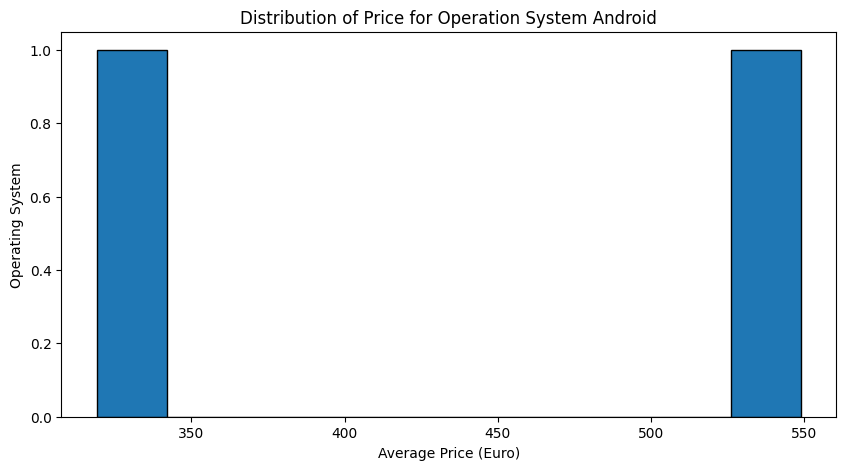

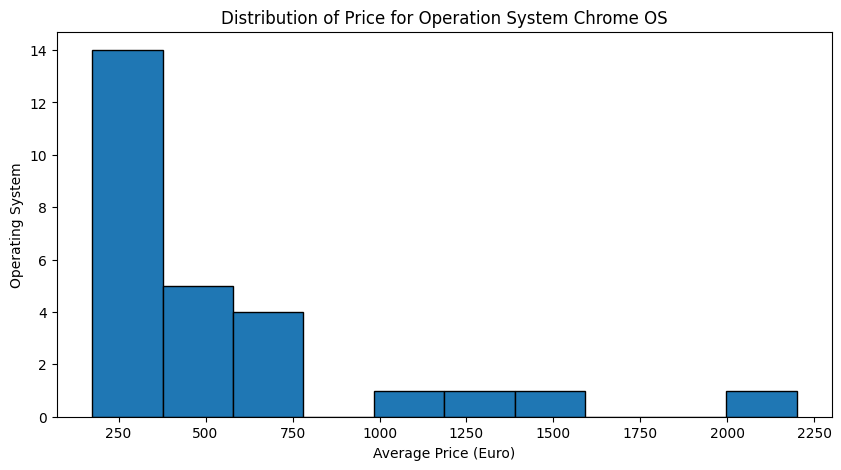

In [ ]:
def plot_os_distribution_price(laptop_data: pd.DataFrame, os_name: str):
    # TODO change all magicstrings here to consts
    fig, ax = plt.subplots(figsize=(10, 5))
    os_data = laptop_data[laptop_data["OpSys"] == os_name]
    ax.hist(os_data["Price (Euro)"], edgecolor="black")
    ax.set_title(f"Distribution of Price for Operation System {os_name}")
    ax.set_xlabel("Average Price (Euro)")
    ax.set_ylabel("Operating System")
    return fig

for os_name in unique_opsys:
    plot_os_distribution_price(new_laptop_data, os_name)

plt.show()

5. What is the relationship between RAM and computer price? add an adequate plot to support your findings. <<< check data for outliers, what would be considered as an outlier? How will you detect it ? >>>

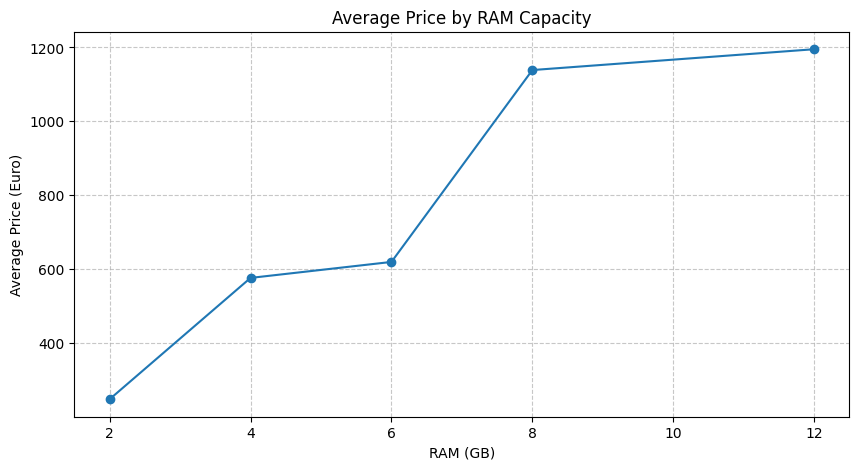

Correlation between RAM and price without Outliers: 0.6030851549269258


In [ ]:
def remove_outliers(df, column):
    """
    Removes outliers from a specific column using the IQR method.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


def plot_ram_and_price(laptop_data: pd.DataFrame):
    # TODO change all magicstrings here to consts
    copy_data = laptop_data.copy()
    data_cleaned = remove_outliers(copy_data, "RAM (GB)")
    data_cleaned = remove_outliers(data_cleaned, "Price (Euro)")
    avg_price_by_ram = (
        data_cleaned.groupby("RAM (GB)")["Price (Euro)"].mean().reset_index()
    )
    avg_price_by_ram = avg_price_by_ram.sort_values("RAM (GB)")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        avg_price_by_ram["RAM (GB)"],
        avg_price_by_ram["Price (Euro)"],
        marker="o",
        linestyle="-",
    )
    ax.set_title("Average Price by RAM Capacity")
    ax.set_xlabel("RAM (GB)")
    ax.set_ylabel("Average Price (Euro)")
    ax.grid(True, linestyle="--", alpha=0.7)
    return fig

plot_ram_and_price(new_laptop_data)
plt.show()

# This is only for the print statement below
new_laptop_data_cleaned = laptop_data.copy()
new_laptop_data_cleaned = remove_outliers(new_laptop_data_cleaned, "RAM (GB)")
new_laptop_data_cleaned = remove_outliers(new_laptop_data_cleaned, "Price (Euro)")
   
print(
        f"Correlation between RAM and price without Outliers: {new_laptop_data_cleaned["RAM (GB)"].corr(new_laptop_data_cleaned["Price (Euro)"])}"
    )

6. Create a new column for the dataframe called "Storage type" that extracts the storage type from the column "Memory".
For example, in the first row in the column "Memory" it states "128GB SSD", the new column will have just "SSD" in its first row.

I chose to use regex to solve this problem.

In [ ]:
import re 

def clean_memory_string(memory_string):
    # TODO change Memory to a const
    cleaned = re.sub(r"[0-9.]+|GB|TB|MB", "", memory_string, flags=re.IGNORECASE)
    # Clean up whitespace (strip and collapse multiple spaces)
    return " ".join(cleaned.split())


def create_storage_column(laptop_data: pd.DataFrame):
    # TODO change Memory and Storage Type to a const
    """
    Takes a DataFrame, extracts the storage technology from 'Memory'
    by removing capacities (GB/TB) and numbers with regex, and adds a 'Storage Type' column.
    Regex breakdown:
    [0-9.]+ -> Matches digits and decimals (e.g., 128, 1.0)
    GB|TB|MB -> Matches the units (case insensitive)
    \\s+ -> Matches extra whitespace
    """
    new_laptop_data = laptop_data.copy()
    # Apply the cleaning logic to the Memory column
    new_laptop_data["Storage Type"] = new_laptop_data["Memory"].apply(
        clean_memory_string
    )

    return new_laptop_data

new_laptop_data = create_storage_column(new_laptop_data)
new_laptop_data.head()


,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Storage Type
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,SSD
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,Flash Storage
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,SSD
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,SSD
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,SSD
